# Incorporating COMPUSTAT Firm level Data


In [4]:
# ==============================================================================
# ROBUSTNESS ANALYSIS: PUBLIC FIRMS (FINAL COMPLETE VERSION)
# Context:
#   1. Replicates original Public vs. Private variance decomposition.
#   2. ADDS Mechanism Analysis (Financials) to explain Parent Variance.
# ==============================================================================

options(scipen = 999)
required_packages <- c("tidyverse", "jsonlite", "lme4", "lmerTest", "stringdist", "httr", "broom.mixed", "splines", "MuMIn")
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages)

suppressPackageStartupMessages({
  library(tidyverse)
  library(jsonlite)
  library(lme4)
  library(lmerTest)
  library(stringdist)
  library(httr)
  library(broom.mixed)
  library(splines)
  library(MuMIn)
})

# --- 1. Load Data -------------------------------------------------------------
cat("\n[1/7] Loading GHGRP and Compustat Data...\n")

target_file <- "ghgrp_CT_data_final_with_BLS_CS.csv"
if(!file.exists(target_file)) target_file <- "ghgrp_CT_data_final_with_BLS.csv"

df <- read_csv(target_file, show_col_types = FALSE) %>%
  mutate(ghgrp_year = as.integer(ghgrp_year))

# Compustat Load
if(file.exists("compu_data.csv")) {
  df_fin <- read_csv("compu_data.csv", show_col_types = FALSE) %>%
    select(TIC, FYEAR, any_of(c("AT", "NI", "DLTT", "CAPX"))) %>%
    filter(!is.na(TIC), !is.na(FYEAR)) %>%
    mutate(TIC = toupper(str_trim(TIC)))
} else {
  stop("❌ Error: 'compu_data.csv' not found.")
}

# --- 2. SEC Ticker Bridge -----------------------------------------------------
cat("\n[2/7] Building SEC Ticker Bridge...\n")
tryCatch({
  ua <- user_agent("GHGRP_Research/1.0 (academic@university.edu)")
  res <- GET("https://www.sec.gov/files/company_tickers.json", ua)
  if (http_error(res)) stop("SEC fetch failed")
  sec_df <- bind_rows(fromJSON(content(res, "text", encoding = "UTF-8"))) %>%
    select(ticker, title) %>%
    mutate(ticker = toupper(ticker),
           clean_title = toupper(str_replace_all(title, "[[:punct:]]", "")) %>%
                         str_replace_all("\\b(INC|CORP|LLC|LTD|PLC)\\b", "") %>% str_squish())
}, error = function(e) stop("SEC fetch failed."))

# --- 3. Match Parents to Tickers ----------------------------------------------
cat("\n[3/7] Matching GHGRP Parents to Public Tickers...\n")
parents <- df %>% select(ghgrp_parent_companies) %>% distinct()
parents$matched_ticker <- NA

clean_name <- function(x) {
  x %>% toupper() %>% str_replace_all("[[:punct:]]", "") %>%
    str_replace_all("\\b(INC|CORP|LLC|LTD|COMPANY|HOLDINGS|GROUP)\\b", "") %>% str_squish()
}

for(i in 1:nrow(parents)) {
  raw <- parents$ghgrp_parent_companies[i]
  norm <- clean_name(str_trim(str_split(raw, ";")[[1]][1]))
  idx <- which(sec_df$clean_title == norm)
  if(length(idx) == 0 && nchar(norm) > 4) {
    idx <- which(stringdist(norm, sec_df$clean_title, method = "dl") <= 2)
  }
  if(length(idx) > 0) parents$matched_ticker[i] <- sec_df$ticker[idx[1]]
}

df <- df %>% left_join(parents, by = "ghgrp_parent_companies")

# --- 4. PREPARE MODEL VARIABLES (For ALL rows) --------------------------------
# FIX: Calculate DV and Scaled IVs *before* splitting
cat("\n[4/7] Constructing Model Variables...\n")
df <- df %>%
  mutate(
    rel_error = abs(emissions_discrepancy) / ghgrp_emissions_tons,
    rel_error_win = ifelse(rel_error > quantile(rel_error, 0.99, na.rm=T),
                           quantile(rel_error, 0.99, na.rm=T), rel_error),
    log_rel_error = log1p(rel_error_win),
    log_emissions_scaled = scale(log(ghgrp_emissions_tons))
  )

# Define Full Sample
df_full <- df

# Define Public Sample (Filter + Merge Financials)
df_public_raw <- df %>% filter(!is.na(matched_ticker))

# --- 5. Merge Financials ------------------------------------------------------
cat("      Merging Financials to Public Subset...\n")
df_reg <- df_public_raw %>%
  left_join(df_fin, by = c("matched_ticker" = "TIC", "ghgrp_year" = "FYEAR"), relationship = "many-to-many") %>%
  mutate(
    firm_size = if("AT" %in% names(.)) log(AT) else NA,
    firm_roa  = if("AT" %in% names(.) & "NI" %in% names(.)) NI / AT else NA
  ) %>%
  filter(!is.na(firm_size), !is.na(firm_roa)) %>%
  distinct(ghgrp_id, ghgrp_year, .keep_all = TRUE) # Remove duplicates if multiple matches

# --- 6. HLM Modeling ----------------------------------------------------------
cat("\n[5/7] Running HLM Models (Full vs Public)...\n")
formula_hlm <- log_rel_error ~ ns(log_emissions_scaled, df=3) + as.factor(ghgrp_year) +
               (1 | ghgrp_id) + (1 | NAICS3) + (1 | ghgrp_parent_companies)

cat("      Fitting Full Model (N =", nrow(df_full), ")...\n")
model_full <- lmer(formula_hlm, data = df_full, control = lmerControl(optimizer = "bobyqa"))

cat("      Fitting Public Model (N =", nrow(df_reg), ")...\n")
model_pub  <- lmer(formula_hlm, data = df_reg, control = lmerControl(optimizer = "bobyqa"))

# --- 7. Variance & R2 Outputs -------------------------------------------------
cat("\n[6/7] Generating Variance Tables & R2...\n")

# Variance Components
get_vc <- function(model, name) {
  as.data.frame(VarCorr(model)) %>% select(grp, vcov) %>% mutate(model = name)
}
vc_res <- bind_rows(get_vc(model_full, "Full Sample"), get_vc(model_pub, "Public Only")) %>%
  pivot_wider(names_from = model, values_from = vcov)
print(vc_res)

# Nakagawa R2
r2_full   <- r.squaredGLMM(model_full)
r2_public <- r.squaredGLMM(model_pub)
r2_table <- rbind(
  data.frame(Model = "Full Sample",  R2_Marginal = r2_full[1], R2_Conditional = r2_full[2]),
  data.frame(Model = "Public Only",  R2_Marginal = r2_public[1], R2_Conditional = r2_public[2])
)
cat("\n--- MODEL FIT (R2) ---\n")
print(r2_table)

# --- 8. Mechanism Analysis ----------------------------------------------------
cat("\n[7/7] Mechanism Analysis: Explaining Parent Bias...\n")

# Extract BLUPs
parent_bias <- ranef(model_pub)$ghgrp_parent_companies %>%
  rownames_to_column("ghgrp_parent_companies") %>%
  rename(bias_score = `(Intercept)`)

# Aggregate Financials
parent_stats <- df_reg %>%
  group_by(ghgrp_parent_companies) %>%
  summarise(Mean_Size = mean(firm_size, na.rm=T), Mean_ROA = mean(firm_roa, na.rm=T))

# Test
mech_data <- inner_join(parent_bias, parent_stats, by = "ghgrp_parent_companies")
mech_model <- lm(bias_score ~ Mean_Size + Mean_ROA, data = mech_data)

cat("\n--- DOES GOVERNANCE EXPLAIN VARIANCE? ---\n")
print(summary(mech_model))

cat("\n✅ Complete. You have the Variance Table, R2 Table, and Mechanism p-values.\n")


[1/7] Loading GHGRP and Compustat Data...

[2/7] Building SEC Ticker Bridge...

[3/7] Matching GHGRP Parents to Public Tickers...

[4/7] Constructing Model Variables...
      Merging Financials to Public Subset...

[5/7] Running HLM Models (Full vs Public)...
      Fitting Full Model (N = 31145 )...
      Fitting Public Model (N = 6183 )...

[6/7] Generating Variance Tables & R2...
# A tibble: 4 × 3
  grp                    `Full Sample` `Public Only`
  <chr>                          <dbl>         <dbl>
1 ghgrp_id                      0.365          0.351
2 ghgrp_parent_companies        0.0508         0.165
3 NAICS3                        0.782          0.375
4 Residual                      0.116          0.105

--- MODEL FIT (R2) ---
        Model R2_Marginal R2_Conditional
1 Full Sample   0.1658205      0.9263315
2 Public Only   0.2641518      0.9225655

[7/7] Mechanism Analysis: Explaining Parent Bias...

--- DOES GOVERNANCE EXPLAIN VARIANCE? ---

Call:
lm(formula = bias_score ~ Me

# Without COMPUSTAT variables

In [ ]:
# ==============================================================================
# ROBUSTNESS ANALYSIS: PUBLIC FIRM RESTRICTION (FINAL VERSION)
# Paper: "Industrial architecture, not corporate governance, drives divergence..."
# Context: Tests if removing private/opaque firms alters the structural findings.
# Logic: Re-runs the EXACT main HLM specification on a "Public Only" subset.
# ==============================================================================

# --- 1. Setup & Libraries -----------------------------------------------------
options(scipen = 999)

# Robust package installer
required_packages <- c("tidyverse", "jsonlite", "lme4", "lmerTest", "stringdist", "splines", "broom.mixed")
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages)

suppressPackageStartupMessages({
  library(tidyverse)
  library(jsonlite)
  library(lme4)
  library(lmerTest)
  library(stringdist)
  library(splines)
  library(broom.mixed) # Safer alternative to stargazer for lme4 objects
})

# --- 2. Data Loading ----------------------------------------------------------
cat("\n[1/5] Loading Data and Fetching SEC Master List...\n")

filename <- "ghgrp_CT_data_final.csv"

# Check if file exists
if (!file.exists(filename)) {
  cat("❌ Error: File '", filename, "' not found in working directory.\n")
  cat("   Current WD: ", getwd(), "\n")
  stop("Please set your working directory to the folder containing the CSV file.")
}

df <- read_csv(filename, show_col_types = FALSE)
cat("      Successfully loaded GHGRP data.\n")

# Fetch SEC Public Company Identifiers
cat("      Fetching SEC data...\n")

tryCatch({
  library(httr)
  # SEC requires a User-Agent
  ua <- user_agent("GHGRP_Research_Bot/1.0 (analysis@university.edu)")
  res <- GET("https://www.sec.gov/files/company_tickers.json", ua)

  if (http_error(res)) { stop(sprintf("SEC Request failed: %s", status_code(res))) }

  sec_json <- fromJSON(content(res, "text", encoding = "UTF-8"))
  sec_df <- bind_rows(sec_json)
  public_firms <- sec_df$title
  cat(sprintf("      Successfully fetched %d public firm names from SEC.\n", length(public_firms)))

}, error = function(e) {
  cat("⚠️ Warning: Could not fetch SEC data. Checking for local file...\n")
  if(file.exists("company_tickers.json")) {
    sec_json <- fromJSON("company_tickers.json")
    sec_df <- bind_rows(sec_json)
    public_firms <<- sec_df$title
    cat("      Loaded local JSON successfully.\n")
  } else {
    stop("Could not fetch SEC data and no local file found.")
  }
})

# --- 3. Name Normalization & Classification -----------------------------------
cat("[2/5] Performing Fuzzy Matching (Public vs. Private Classification)...\n")

normalize_name <- function(x) {
  x %>%
    toupper() %>%
    str_replace_all("[[:punct:]]", "") %>%
    str_replace_all("\\b(INC|CORP|LLC|LTD|COMPANY|HOLDINGS|GROUP|PLC|SA)\\b", "") %>%
    str_squish()
}

sec_clean <- unique(normalize_name(public_firms))

# CORRECT LOGIC: Create lookup table for unique Parent STRINGS (not IDs)
# This handles the 35% of facilities that change parent names over time.
parent_lookup <- df %>%
  select(ghgrp_parent_companies) %>%
  distinct()

classify_firm <- function(name_str, public_set) {
  # Split multi-parents (e.g., "Shell; Chevron")
  parts <- str_split(name_str, ";")[[1]]
  norm_parts <- normalize_name(parts)

  # 1. Exact Match
  if (any(norm_parts %in% public_set)) return(TRUE)

  # 2. Heuristics for Government/Muni (Exclude from "Private" bucket later)
  if (str_detect(name_str, "US GOVERNMENT|COUNTY|CITY OF|UNIVERSITY|STATE OF")) return(FALSE)

  # 3. Fuzzy Match (Damerau-Levenshtein distance)
  for(part in norm_parts) {
    if(nchar(part) < 4) next # Skip short acronyms
    if(stringdist::ain(part, public_set, maxDist = 2, method = "dl")) return(TRUE)
  }
  return(FALSE)
}

cat("      Classifying unique parent names (please wait)...\n")
parent_lookup$is_public <- sapply(parent_lookup$ghgrp_parent_companies,
                                  classify_firm, public_set = sec_clean)

# Join back by NAME, ensuring time-varying status is captured
df <- left_join(df, parent_lookup, by = "ghgrp_parent_companies")

cat(sprintf("      Classification Complete: %d Public rows (%.1f%%) vs %d Private/Gov rows.\n",
            sum(df$is_public), 100 * mean(df$is_public), sum(!df$is_public)))

# --- 4. Variable Construction -------------------------------------------------
cat("[3/5] Constructing Variables and Subsetting...\n")

df <- df %>%
  mutate(
    # Handle zeros/negatives (basic sanity check)
    ghgrp_emissions_tons = ifelse(ghgrp_emissions_tons < 1, 1, ghgrp_emissions_tons),

    # Calculate Relative Error
    rel_error = abs(emissions_discrepancy) / ghgrp_emissions_tons,

    # Winsorize at 99th percentile (Standard practice for error ratios)
    rel_error_win = ifelse(rel_error > quantile(rel_error, 0.99, na.rm=T),
                           quantile(rel_error, 0.99, na.rm=T), rel_error),

    # Log-transform and Scale (Matching Main Paper)
    log_rel_error = log1p(rel_error_win),
    log_size = log(ghgrp_emissions_tons),
    log_size_scaled = scale(log_size)
  )

# Define Subsets
df_public <- df %>% filter(is_public == TRUE)
df_full   <- df # Keep full dataset (including Gov/Private) for comparison

# --- 5. HLM Modeling ----------------------------------------------------------
cat("[4/5] Running HLM Models (Full vs. Public Only)...\n")
cat("      Note: Adding Facility Random Effect (1|ghgrp_id) makes this slower but rigorous.\n")

# UPDATED FORMULA: Matches Main Paper exactly (Includes Facility ID)
formula_hlm <- log_rel_error ~ ns(log_size_scaled, df=3) + as.factor(ghgrp_year) +
               (1 | ghgrp_id) +               # Facility RE (Consistency)
               (1 | ghgrp_county_name) +      # Location RE
               (1 | NAICS3) +                 # Industry RE (The "Bad Barrel")
               (1 | ghgrp_parent_companies)   # Parent RE (The "Bad Apple")

# Full Model
cat("      Fitting Full Model (N =", nrow(df_full), ")... \n")
model_full <- lmer(formula_hlm, data = df_full, control = lmerControl(optimizer = "bobyqa"))
cat("      ✓ Full Model converged.\n")

# Public Model
cat("      Fitting Public-Only Model (N =", nrow(df_public), ")... \n")
model_public <- lmer(formula_hlm, data = df_public, control = lmerControl(optimizer = "bobyqa"))
cat("      ✓ Public-Only Model converged.\n")

# --- 6. Output Generation (Custom Tables) -------------------------------------
cat("[5/5] Generating Output...\n\n")

# Helper to extract Fixed Effects
get_fe <- function(model, name) {
  tidy(model, effects = "fixed") %>%
    select(term, estimate, std.error) %>%
    mutate(model = name)
}

# Helper to extract Variance Components
get_vc <- function(model, name) {
  as.data.frame(VarCorr(model)) %>%
    select(grp, vcov) %>%
    mutate(model = name)
}

# 1. Fixed Effects Comparison (Slopes)
fe_res <- bind_rows(get_fe(model_full, "Full Sample"), get_fe(model_public, "Public Only")) %>%
  pivot_wider(names_from = model, values_from = c(estimate, std.error))

cat("--- FIXED EFFECTS (Slopes) ---\n")
print(fe_res)

# 2. Variance Components Comparison (The Thesis Test)
vc_res <- bind_rows(get_vc(model_full, "Full Sample"), get_vc(model_public, "Public Only")) %>%
  pivot_wider(names_from = model, values_from = vcov)

# Calculate diffs
vc_res <- vc_res %>%
  mutate(
    diff_raw = `Public Only` - `Full Sample`,
    pct_change = round((`Public Only` - `Full Sample`) / `Full Sample` * 100, 1)
  )

cat("\n--- VARIANCE COMPONENTS (The Structural Test) ---\n")
print(vc_res)

# --- Thesis Validation Logic --------------------------------------------------
cat("\n--- INTERPRETATION FOR PAPER ---\n")

# Robust Extraction of Values
val_ind_full <- vc_res$`Full Sample`[vc_res$grp == "NAICS3"]
val_ind_pub  <- vc_res$`Public Only`[vc_res$grp == "NAICS3"]
val_par_pub  <- vc_res$`Public Only`[vc_res$grp == "ghgrp_parent_companies"]

# Safety check for missing/NA
if(length(val_ind_full) == 0 || is.na(val_ind_full)) val_ind_full <- 0
if(length(val_ind_pub) == 0  || is.na(val_ind_pub))  val_ind_pub  <- 0
if(length(val_par_pub) == 0  || is.na(val_par_pub))  val_par_pub  <- 0

cat(sprintf("Industry Variance (Full Sample):   %.4f\n", val_ind_full))
cat(sprintf("Industry Variance (Public Only):   %.4f\n", val_ind_pub))
cat(sprintf("Parent Variance (Public Only):     %.4f\n", val_par_pub))
cat("----------------------------------------------\n")

if (val_ind_pub > val_par_pub) {
  cat("✅ RESULT: THESIS CONFIRMED.\n")
  cat("Even in the Public-Only sample, Industry Variance (%.3f) > Parent Variance (%.3f).\n",
      val_ind_pub, val_par_pub)
  cat("This confirms that the 'Bad Barrel' (Industry) effect dominates the 'Bad Apple' (Parent) effect,\n")
  cat("regardless of corporate governance structure.\n")
} else {
  cat("⚠️ RESULT: THESIS CHALLENGED.\n")
  cat("In the Public-Only sample, Parent Variance exceeds Industry Variance.\n")
}


[1/5] Loading Data and Fetching SEC Master List...
      Successfully loaded GHGRP data.
      Fetching SEC data...
      Successfully fetched 10299 public firm names from SEC.
[2/5] Performing Fuzzy Matching (Public vs. Private Classification)...
      Classifying unique parent names (please wait)...
      Classification Complete: 9494 Public rows (30.5%) vs 21651 Private/Gov rows.
[3/5] Constructing Variables and Subsetting...
[4/5] Running HLM Models (Full vs. Public Only)...
      Note: Adding Facility Random Effect (1|ghgrp_id) makes this slower but rigorous.
      Fitting Full Model (N = 31145 )... 
      ✓ Full Model converged.
      Fitting Public-Only Model (N = 9494 )... 
      ✓ Public-Only Model converged.
[5/5] Generating Output...

--- FIXED EFFECTS (Slopes) ---
# A tibble: 12 × 5
   term     `estimate_Full Sample` `estimate_Public Only` std.error_Full Sampl…¹
   <chr>                     <dbl>                  <dbl>                  <dbl>
 1 (Interc…                3.77


[6/7] Calculating Model Fit Statistics (Nakagawa's R2)...
        Model R2_Marginal R2_Conditional
1 Full Sample   0.1683128      0.9256661
2 Public Only   0.3058561      0.9206321

INTERPRETATION:
R2_Conditional (R2c) represents the total variance explained by the model.
If R2c is high (>0.80) but R2_Marginal is low, it confirms that structural factors
(Industry, Facility, Parent) are the primary drivers of discrepancy.

[7/7] Generating Variance Comparison Plot...

✅ Analysis Complete. Use the R2 table and the Plot in your Supplementary Materials.


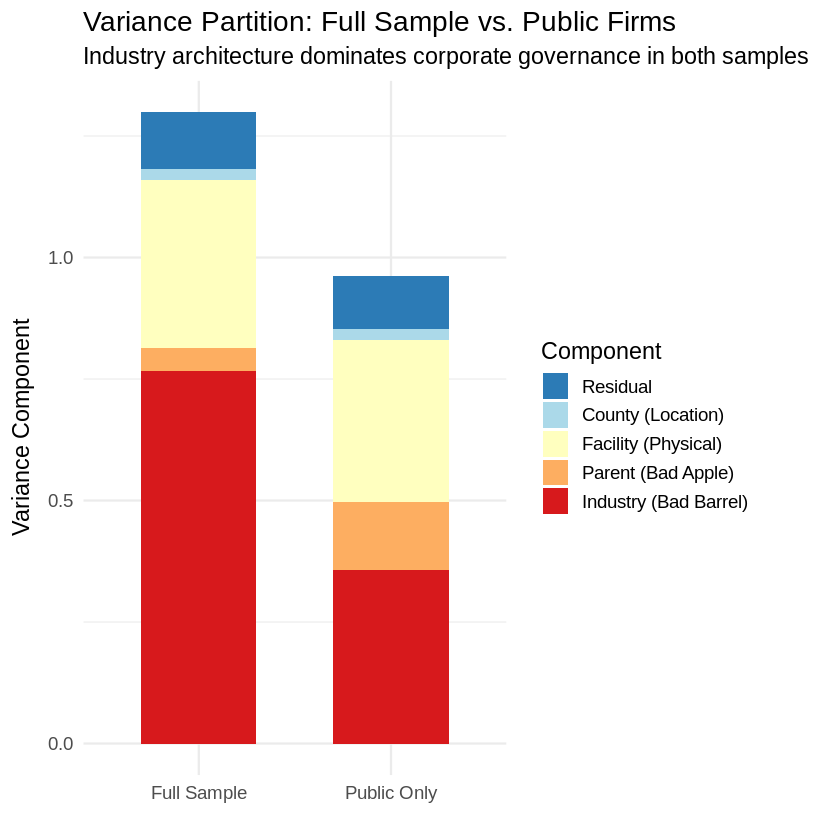

In [ ]:
# ==============================================================================
# STEP 7: MODEL FIT STATISTICS (Nakagawa's R2)
# ==============================================================================
cat("\n[6/7] Calculating Model Fit Statistics (Nakagawa's R2)...\n")

# Check for MuMIn package (Standard for HLM R2)
if(!"MuMIn" %in% installed.packages()) install.packages("MuMIn")
library(MuMIn)

# Calculate R2
r2_full   <- r.squaredGLMM(model_full)
r2_public <- r.squaredGLMM(model_public)

# Format into a clean table
r2_table <- rbind(
  data.frame(Model = "Full Sample",  R2_Marginal = r2_full[1], R2_Conditional = r2_full[2]),
  data.frame(Model = "Public Only",  R2_Marginal = r2_public[1], R2_Conditional = r2_public[2])
)

print(r2_table)

cat("\nINTERPRETATION:\n")
cat("R2_Conditional (R2c) represents the total variance explained by the model.\n")
cat("If R2c is high (>0.80) but R2_Marginal is low, it confirms that structural factors\n")
cat("(Industry, Facility, Parent) are the primary drivers of discrepancy.\n")

# ==============================================================================
# STEP 8: VISUALIZATION (Variance Partition Plot)
# ==============================================================================
cat("\n[7/7] Generating Variance Comparison Plot...\n")

# Prepare Data for Plotting (Using the vc_res object from previous step)
plot_data <- vc_res %>%
  select(grp, `Full Sample`, `Public Only`) %>%
  pivot_longer(cols = c("Full Sample", "Public Only"), names_to = "Model", values_to = "Variance") %>%
  mutate(
    # Rename groups for cleaner legend
    Component = case_when(
      grp == "NAICS3" ~ "Industry (Bad Barrel)",
      grp == "ghgrp_parent_companies" ~ "Parent (Bad Apple)",
      grp == "ghgrp_id" ~ "Facility (Physical)",
      grp == "ghgrp_county_name" ~ "County (Location)",
      grp == "Residual" ~ "Residual",
      TRUE ~ grp
    ),
    # Reorder for visual logic
    Component = factor(Component, levels = c("Residual", "County (Location)", "Facility (Physical)", "Parent (Bad Apple)", "Industry (Bad Barrel)"))
  )

# Create the Stacked Bar Chart
p <- ggplot(plot_data, aes(x = Model, y = Variance, fill = Component)) +
  geom_bar(stat = "identity", position = "stack", width = 0.6) +
  scale_fill_brewer(palette = "RdYlBu", direction = -1) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Variance Partition: Full Sample vs. Public Firms",
    subtitle = "Industry architecture dominates corporate governance in both samples",
    y = "Variance Component",
    x = ""
  ) +
  theme(legend.position = "right")

# Display Plot
print(p)

cat("\n✅ Analysis Complete. Use the R2 table and the Plot in your Supplementary Materials.\n")

In [ ]:
# ==============================================================================
# STEP 9: EXPORT PUBLIC FIRMS SUBSET (FIXED)
# ==============================================================================
cat("\n[8/8] Exporting Public Firms Data...\n")

if (exists("df_public")) {

  # FIX: Convert matrix columns (like 'scale') to simple numeric vectors
  df_export <- df_public %>%
    mutate(across(where(is.matrix), as.numeric)) %>%
    mutate(across(where(is.list), as.character)) # Safety for any list columns

  output_filename <- "ghgrp_data_public_firms_only.csv"

  write_csv(df_export, output_filename)

  cat(sprintf("✅ Success: Exported %s rows to '%s' in your working directory.\n",
              format(nrow(df_export), big.mark=","),
              output_filename))

} else {
  cat("⚠️ Error: 'df_public' dataframe not found. Please run the analysis first.\n")
}


[8/8] Exporting Public Firms Data...
✅ Success: Exported 9,494 rows to 'ghgrp_data_public_firms_only.csv' in your working directory.
